In [1]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

In [3]:

X, y, coef = make_regression(n_samples=100,
                              n_features=1,
                              n_informative=1,
                              noise=10,
                              coef=True,
                              random_state=0,
                              bias=100.0)

In [5]:
def compute_mse(coefs, X, y):
    a, b = coefs
    y_preds = a * X.reshape(-1) + b
    mse = np.mean((y_preds - y) ** 2)
    return mse

In [6]:
# test 

In [8]:
print(compute_mse([1, 2], X, y))

11808.867339751561


In [9]:
# build the grid

In [11]:
aa, bb = np.mgrid[-200:200:0.5, -200:200:0.5]
grid = np.c_[aa.ravel(), bb.ravel()]

print(grid.shape)

(640000, 2)


In [12]:
from functools import partial
from multiprocessing import Pool


In [13]:
compute_mse_partial = partial(compute_mse, X=X, y=y)

In [16]:

with Pool() as pool:
    losses = pool.map(compute_mse_partial, grid)
print(len(losses))

640000


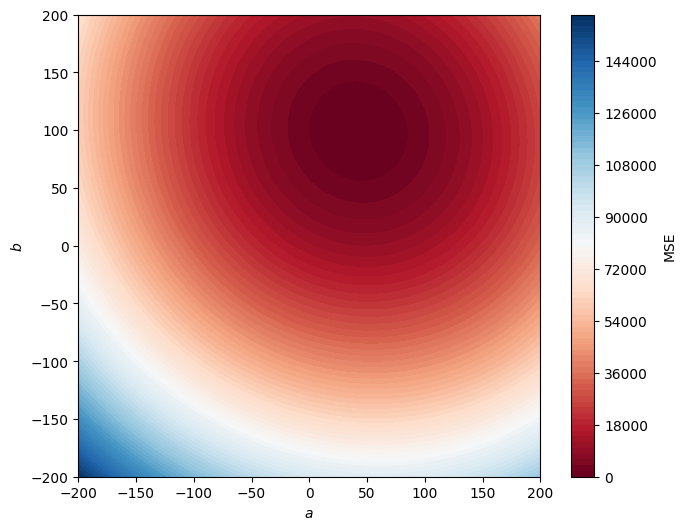

In [17]:
losses_reshaped = np.array(losses).reshape(aa.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(aa, bb, losses_reshaped, 100, cmap="RdBu", vmin=0, vmax=160000)
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")

ax.set(aspect="equal",
       xlim=(-200, 200),
       ylim=(-200, 200),
       xlabel="$a$",
       ylabel="$b$")

plt.show()